# Popper: check the statement, then prove it

*Popper* is the system; **`falsify`** is the package that runs it. This notebook
walks through the whole thing, end to end, and finishes with the benchmark.

The idea in one sentence: when you verify code or math with a computer, you write
a statement of what is supposed to be true (a "spec") and prove your work matches
it, but the statement itself can be wrong, and a proof checker will not tell you.
Popper goes after the statement directly. It tries to break the statement, and
when it finds an input that breaks it, it hands you that input (a counterexample).

What I cover:

1. the idea in one worked example (KL divergence),
2. the math engine on a ladder of real theorems,
3. **the benchmark**: Popper vs a proof checker vs an LLM judge, with charts,
4. why the score is not a flat 100% (detection vs search budget),
5. the code-spec engine and the repair loop,
6. the live Verina check over the Axiom Lean Engine (AXLE).

In [1]:
import os
import sys

for p in (os.path.abspath("."), os.path.abspath("..")):
    if p not in sys.path:
        sys.path.insert(0, p)

import falsify
print("falsify", falsify.__version__)

# Plotting is optional. The core of Popper is standard-library only; matplotlib is
# used here just to draw the charts. If it is missing, the notebook still runs and
# prints the same numbers as text.
try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except Exception:
    HAVE_MPL = False
    print("matplotlib not found; charts will print as text. `pip install matplotlib` for plots.")

falsify 0.3.0


Matplotlib is building the font cache; this may take a moment.


## 1. The idea in one example: KL divergence

Gibbs' inequality says the KL divergence between two probability distributions is
never negative. KL is a standard way to measure how different two distributions
are, and it is written

$$\mathrm{KL}(p \| q) = \sum_i p_i \log \frac{p_i}{q_i} \ge 0.$$

This is true, but only when $q$ is a real distribution, meaning $\sum_i q_i = 1$.
A very common mistake when writing the formal statement is to forget that
assumption. Below I compute KL on thousands of random cases: once with $q$ a
proper distribution, and once with $q$ just any non-negative vector. When the
assumption is dropped, KL goes negative, and the statement is simply false.

q is a real distribution      : min KL = +0.000   (never negative)
q not required to sum to 1    : min KL = -2.125   (goes negative: the bug)
fraction of negative KL values: 92.7%


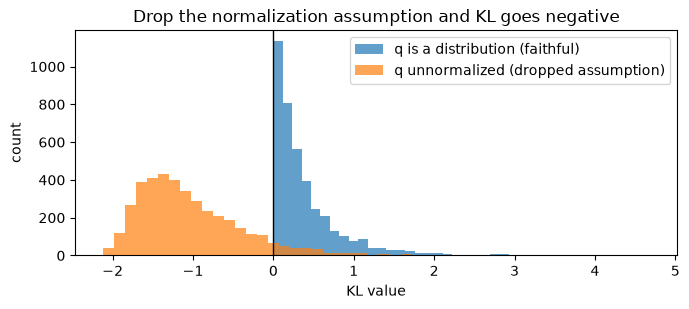

In [2]:
import random
from falsify.montecarlo.numerical import kl_divergence, random_prob_vector, random_nonneg_vector

rng = random.Random(0)
K, N = 3, 4000
kl_ok = [kl_divergence(random_prob_vector(K, rng), random_prob_vector(K, rng)) for _ in range(N)]
kl_bad = [kl_divergence(random_prob_vector(K, rng), random_nonneg_vector(K, rng)) for _ in range(N)]

print(f"q is a real distribution      : min KL = {min(kl_ok):+.3f}   (never negative)")
print(f"q not required to sum to 1    : min KL = {min(kl_bad):+.3f}   (goes negative: the bug)")
print(f"fraction of negative KL values: {sum(v < 0 for v in kl_bad) / N:.1%}")

if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.hist(kl_ok, bins=40, alpha=0.7, label="q is a distribution (faithful)")
    ax.hist(kl_bad, bins=40, alpha=0.7, label="q unnormalized (dropped assumption)")
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel("KL value"); ax.set_ylabel("count")
    ax.set_title("Drop the normalization assumption and KL goes negative")
    ax.legend(); plt.tight_layout(); plt.show()

Every negative value on the left of zero is a counterexample to the buggy
statement. That is the whole trick: a statement that looks fine on paper breaks
on a concrete input, and the input tells you exactly what went wrong.

## 2. The math engine on a ladder of theorems

The same check runs over a curated ladder of information-theory statements. Each
faithful statement is paired with a broken twin (a dropped assumption or a
flipped direction). Faithful ones survive; broken ones are refuted with the
violating instance. This is "Monte-Carlo", which just means trying many random
inputs and watching for one that breaks the statement.

In [3]:
from falsify import NumericalOracle, information_theory_library, run_audit

rep = run_audit(information_theory_library(), NumericalOracle(),
                "Numerical oracle - information theory")
print(rep.render_terminal())


=== Numerical oracle - information theory ===
7 claims | ✓ FAITHFUL 3  ✗ FALSIFIED 3  ? INCONCLUSIVE 1
✓ [FAITHFUL    ] kl_nonneg: survived 2000 Monte-Carlo draws (2000 with hypothesis active)
✗ [FALSIFIED   ] kl_nonneg_DROPPED_normalization: counterexample found; the formalized statement is false as written  ⟵ q=[0.777, 1.534, 1.215] (Σq=3.525≠1) ⇒ Σ pᵢ·log(pᵢ/qᵢ) = -1.1543 < 0
✓ [FAITHFUL    ] data_processing: survived 2000 Monte-Carlo draws (2000 with hypothesis active)
✗ [FALSIFIED   ] data_processing_DROPPED_markov: counterexample found; the formalized statement is false as written  ⟵ I(X;Z) = 0.8318 > I(X;Y) = 0.0478  (Z leaks X directly)
✓ [FAITHFUL    ] entropy_concave: survived 2000 Monte-Carlo draws (2000 with hypothesis active)
✗ [FALSIFIED   ] entropy_concave_WRONG_direction: counterexample found; the formalized statement is false as written  ⟵ H(λp+(1-λ)q) = 1.0797 > λH(p)+(1-λ)H(q) = 1.0600  (entropy is concave, not convex)
? [INCONCLUSIVE] entropy_uniform_vacuous_guard:

## 3. The benchmark: Popper vs a proof checker vs an LLM judge

The benchmark is a set of statements I labelled by hand as faithful or unfaithful.
The task is simple: flag the broken ones, leave the good ones alone. Three
checkers run over the same set.

- **Proof checker (Lean / AXLE alone)**: it confirms a proof matches a statement.
  Every spec here is valid as a proof, so it accepts all of them and flags none.
  That is not a weakness of the prover; catching a bad spec is just not its job.
- **LLM judge**: a model reads the statement and guesses, with no execution. It
  can guess right but never returns the input that breaks the spec. (Runnable live
  with `ANTHROPIC_API_KEY`.)
- **Popper**: the executable oracle in this repo.

In [4]:
from falsify.bench.corpus import benchmark_corpus
from falsify.bench.judges import popper_judge, proof_checker_judge
from falsify.bench.metrics import score_judge

items = benchmark_corpus()
n_surf = {}
for it in items:
    n_surf[it.surface] = n_surf.get(it.surface, 0) + 1
print(f"{len(items)} labelled statements: " + ", ".join(f"{k} {v}" for k, v in n_surf.items()))

popper = score_judge("popper", [(it, popper_judge(it, n_trials=2000)) for it in items])
checker = score_judge("proof_checker", [(it, proof_checker_judge(it)) for it in items])

hdr = f"{'checker':<16}{'caught':>10}{'false alarms':>14}{'counterexample':>16}{'F1':>7}"
print("\n" + hdr); print("-" * len(hdr))
for name, s in (("Popper", popper), ("Proof checker", checker)):
    print(f"{name:<16}{s.tp:>4}/{s.n_unfaithful:<5}"
          f"{s.fp:>8}/{s.n_faithful:<5}"
          f"{s.counterexample_yield:>15.0%}{s.f1:>7.2f}")
print(f"{'LLM judge':<16}{'runnable live (no API key set here)':>40}")

346 labelled statements: math 332, code 4, verina 10



checker             caught  false alarms  counterexample     F1
---------------------------------------------------------------
Popper           176/178         0/165             100%   0.99
Proof checker      0/178         0/165               0%   0.00
LLM judge            runnable live (no API key set here)


Popper catches nearly every broken spec and hands you a counterexample for each
one, with no false alarms. The proof checker catches none. Let me draw that.

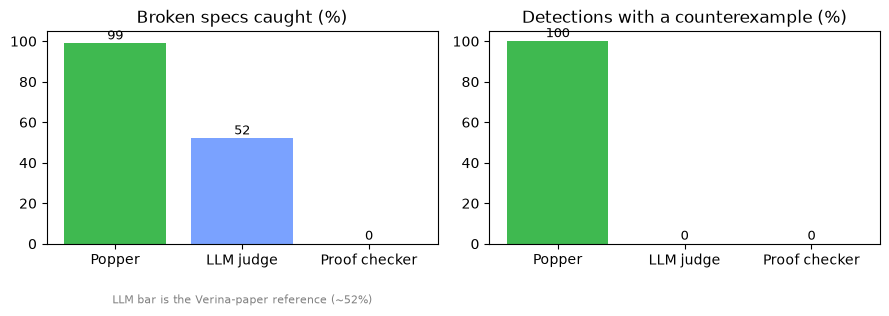

In [5]:
labels = ["Popper", "LLM judge", "Proof checker"]
recall = [popper.recall * 100, 52, checker.recall * 100]   # 52 = Verina paper reference
yield_ = [popper.counterexample_yield * 100, 0, 0]

if HAVE_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
    for ax, vals, title in ((axes[0], recall, "Broken specs caught (%)"),
                            (axes[1], yield_, "Detections with a counterexample (%)")):
        bars = ax.bar(labels, vals, color=["#3fb950", "#7aa2ff", "#f85149"])
        ax.set_ylim(0, 105); ax.set_title(title)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.0f}", ha="center", fontsize=9)
    axes[0].text(0.5, -0.28, "LLM bar is the Verina-paper reference (~52%)",
                 transform=axes[0].transAxes, ha="center", fontsize=8, color="gray")
    plt.tight_layout(); plt.show()
else:
    print("recall %:", dict(zip(labels, recall)))
    print("counterexample yield %:", dict(zip(labels, yield_)))

## 4. Why the score is not a flat 100%: detection vs search budget

An easy bug, like a flipped inequality, fails on about half of all random inputs,
so Popper catches it in a couple of draws. The benchmark also includes subtle
bugs that fail on only a tiny fraction of inputs (down to about 1 in 10,000).
Finding those is a question of how many draws you spend. This is exactly Popper's
stated limitation, and it is why the F1 is a real number that moves with effort,
not a fixed 1.00.

   draws   math recall   math F1   subtle caught   subtle F1
     100          98%      0.99        6/10           0.75
     500          99%      0.99        8/10           0.89
    2000          99%      0.99        8/10           0.89
   10000         100%      1.00       10/10           1.00
   50000         100%      1.00       10/10           1.00


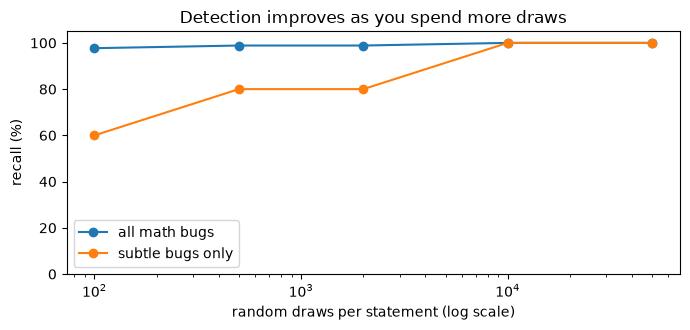

In [6]:
from falsify.bench.run import budget_sweep

sweep = budget_sweep()
print(f"{'draws':>8}{'math recall':>14}{'math F1':>10}{'subtle caught':>16}{'subtle F1':>12}")
for r in sweep:
    print(f"{r['budget']:>8}{r['recall']:>13.0%}{r['f1']:>10.2f}"
          f"{r['rare_caught']:>9}/{r['rare_total']:<5}{r['rare_f1']:>12.2f}")

if HAVE_MPL:
    xs = [r["budget"] for r in sweep]
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(xs, [r["recall"] * 100 for r in sweep], "o-", label="all math bugs")
    ax.plot(xs, [r["rare_recall"] * 100 for r in sweep], "o-", label="subtle bugs only")
    ax.set_xscale("log"); ax.set_ylim(0, 105)
    ax.set_xlabel("random draws per statement (log scale)"); ax.set_ylabel("recall (%)")
    ax.set_title("Detection improves as you spend more draws")
    ax.legend(); plt.tight_layout(); plt.show()

## 5. By kind of bug

A breakdown of how many of each kind of bug Popper caught. The proof checker
caught zero in every row.

  direction-error      122/122
  over-claim            26/26 
  dropped-hypothesis    17/17 
  rare-edge              8/10 
  vacuous                1/1  
  incomplete             1/1  
  unsound                1/1  


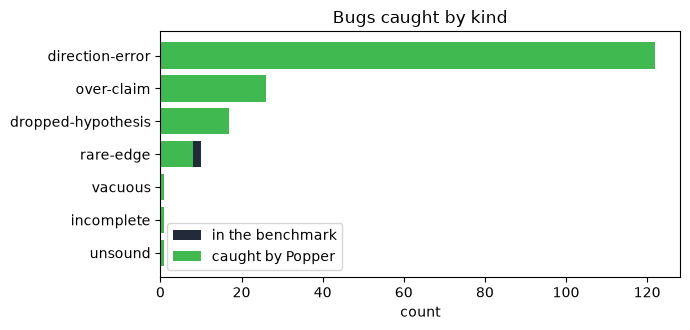

In [7]:
from collections import Counter
fam_total = Counter(it.family for it in items if it.gold_unfaithful)
fam_caught = Counter(it.family for it in items
                     if it.gold_unfaithful and popper_judge(it, n_trials=2000).verdict.is_falsified)

for fam, tot in fam_total.most_common():
    print(f"  {fam:<20} {fam_caught[fam]:>3}/{tot:<3}")

if HAVE_MPL:
    fams = [f for f, _ in fam_total.most_common()]
    totals = [fam_total[f] for f in fams]
    caught = [fam_caught[f] for f in fams]
    fig, ax = plt.subplots(figsize=(7, 3.4))
    y = range(len(fams))
    ax.barh(list(y), totals, color="#232a39", label="in the benchmark")
    ax.barh(list(y), caught, color="#3fb950", label="caught by Popper")
    ax.set_yticks(list(y)); ax.set_yticklabels(fams); ax.invert_yaxis()
    ax.set_xlabel("count"); ax.set_title("Bugs caught by kind"); ax.legend()
    plt.tight_layout(); plt.show()

## 6. Code specs and repair

The math engine works on numbers. For code, each task ships a correct answer and
several wrong ones, and Popper asks whether the spec accepts the right answer and
rejects the wrong ones. A rejected correct answer means the spec is too tight; an
accepted wrong answer means it is too loose; an accepted nonsense answer means it
is empty. This offline version uses an executable model, so no Lean is needed.

In [8]:
from falsify import CodeSpecOracle, MockAxleClient, verina_like_tasks

rep = run_audit(verina_like_tasks(), CodeSpecOracle(MockAxleClient()),
                "Code-spec oracle - offline fixtures")
print(rep.render_terminal())


=== Code-spec oracle - offline fixtures ===
4 claims | ✓ FAITHFUL 1  ✗ UNSOUND 1  ✗ INCOMPLETE 1  ✗ VACUOUS 1
✗ [VACUOUS     ] sort_by_length: spec constrains nothing; even the throwaway impl 'all_zeros' satisfies it  ⟵ impl 'all_zeros' passes; spec fails to pin down the answer
✗ [INCOMPLETE  ] max_lower_bound_only: spec is too loose; the wrong impl 'max_plus_one' satisfies it yet disagrees with the reference  ⟵ impl 'max_plus_one' passes the spec; differs from reference at input (3, 5)
✓ [FAITHFUL    ] abs_value: reference passes; no wrong implementation slips through; not vacuous
✗ [UNSOUND     ] abs_strictly_positive: spec is too tight; it rejects the correct reference implementation  ⟵ reference fails spec at input (0,) (→ output 0)



The counterexample is also a repair hint. The repair loop takes the broken spec,
uses the counterexample to adjust it, and checks again, until it holds up.

In [9]:
from falsify import default_repairer, repair_loop

oracle = CodeSpecOracle(MockAxleClient())
for task in verina_like_tasks():
    print(repair_loop(task, oracle, default_repairer()).render())

✓ sort_by_length: ✗VACUOUS  →  ✓FAITHFUL
      first counterexample: impl 'all_zeros' passes; spec fails to pin down the answer
✓ max_lower_bound_only: ✗INCOMPLETE  →  ✓FAITHFUL
      first counterexample: impl 'max_plus_one' passes the spec; differs from reference at input (3, 5)
✓ abs_value: ✓FAITHFUL
✓ abs_strictly_positive: ✗UNSOUND  →  ✓FAITHFUL
      first counterexample: reference fails spec at input (0,) (→ output 0)


## 7. Live Verina over AXLE

The real thing: real benchmark tasks, real Lean. Each task's correct and wrong
outputs become `native_decide` checks run through the Axiom Lean Engine. A
rejected correct output is UNSOUND; an accepted wrong output is INCOMPLETE. This
needs `pip install axiom-axle` and an `AXLE_API_KEY`.

In [10]:
from falsify import run_live_audit

if os.environ.get("AXLE_API_KEY"):
    report = run_live_audit(limit=5, max_tests=1, max_unexpected=2, progress=False)
    print(report.render_terminal())
else:
    print("Set AXLE_API_KEY (and `pip install axiom-axle`) to run the live audit.")
    print("Recorded results from an earlier live run are in results/verina_live.json.")

Set AXLE_API_KEY (and `pip install axiom-axle`) to run the live audit.
Recorded results from an earlier live run are in results/verina_live.json.


## 8. Honesty and limits

Popper breaks statements; it does not certify them. A FAITHFUL verdict means no
counterexample was found within the budget, not that none exists. Proving none
exists is undecidable in general, so I do not claim it. Random sampling can miss a
bug that hides on a tiny set of inputs (that is what section 4 measured), though
dropped assumptions and flipped directions are exactly the bugs that show up under
sampling. Lean and AXLE stay the final word on the proof itself. When a spec
cannot be decided on a test case, Popper says INCONCLUSIVE instead of guessing.